# Raw Rainfall Data Analysis

Phan tich du lieu raw `rain_weather_hourly.csv` truoc khi tien xu ly va tao feature. Notebook nay tap trung vao chat luong du lieu, phan phoi luong mua, pattern theo thoi gian va moi quan he giua cac bien thoi tiet.

## 1. Setup

In [18]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == 'Notebooks' else Path.cwd()
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

from src.aq_course_ml.config import BASE_COLUMNS, RAW_DATA_PATH

plt.style.use('seaborn-v0_8-whitegrid')

## 2. Load Raw Data

In [19]:
raw_df = pd.read_csv(RAW_DATA_PATH, parse_dates=['timestamp'])
raw_df = raw_df.sort_values(['city', 'timestamp']).reset_index(drop=True)

print(f'Raw path: {RAW_DATA_PATH}')
print(f'Rows: {len(raw_df):,}')
print(f'Columns: {len(raw_df.columns):,}')
print(f"Time range: {raw_df['timestamp'].min()} -> {raw_df['timestamp'].max()}")
raw_df.head()

Raw path: D:\air-quality-course-ml\Data\raw\rain_weather_hourly.csv
Rows: 56,112
Columns: 20
Time range: 2020-01-01 00:00:00 -> 2026-05-26 23:00:00


,timestamp,rain,precipitation,temperature_2m,relative_humidity_2m,dew_point_2m,pressure_msl,surface_pressure,wind_speed_10m,wind_direction_10m,wind_gusts_10m,cloud_cover,cloud_cover_low,cloud_cover_mid,cloud_cover_high,et0_fao_evapotranspiration,vapour_pressure_deficit,city,latitude,longitude
0,2020-01-01 00:00:00,0.4,0.4,19.5,93,18.3,1024.1,1022.0,4.6,219,6.8,100,100,100,0,0.0,0.16,Ha Noi,21.0278,105.8342
1,2020-01-01 01:00:00,0.3,0.3,19.4,93,18.2,1023.9,1021.8,4.6,252,6.8,100,100,100,0,0.0,0.15,Ha Noi,21.0278,105.8342
2,2020-01-01 02:00:00,0.1,0.1,19.2,94,18.2,1023.4,1021.3,4.0,270,6.8,100,100,100,0,0.0,0.14,Ha Noi,21.0278,105.8342
3,2020-01-01 03:00:00,0.1,0.1,19.1,94,18.1,1023.4,1021.2,3.1,306,6.1,100,100,97,0,0.0,0.13,Ha Noi,21.0278,105.8342
4,2020-01-01 04:00:00,0.1,0.1,18.9,94,17.9,1023.3,1021.1,5.4,340,7.9,99,99,92,0,0.0,0.13,Ha Noi,21.0278,105.8342


In [20]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56112 entries, 0 to 56111
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   timestamp                   56112 non-null  datetime64[ns]
 1   rain                        56112 non-null  float64       
 2   precipitation               56112 non-null  float64       
 3   temperature_2m              56112 non-null  float64       
 4   relative_humidity_2m        56112 non-null  int64         
 5   dew_point_2m                56112 non-null  float64       
 6   pressure_msl                56112 non-null  float64       
 7   surface_pressure            56112 non-null  float64       
 8   wind_speed_10m              56112 non-null  float64       
 9   wind_direction_10m          56112 non-null  int64         
 10  wind_gusts_10m              56112 non-null  float64       
 11  cloud_cover                 56112 non-null  int64     

## 3. Dataset Coverage

In [21]:
coverage = raw_df.groupby('city').agg(
    rows=('timestamp', 'size'),
    start_time=('timestamp', 'min'),
    end_time=('timestamp', 'max'),
    latitude=('latitude', 'first'),
    longitude=('longitude', 'first'),
)
coverage

,rows,start_time,end_time,latitude,longitude
city,,,,,
Ha Noi,56112,2020-01-01,2026-05-26 23:00:00,21.0278,105.8342


In [22]:
hourly_gaps = []
for city, city_df in raw_df.groupby('city'):
    diffs = city_df['timestamp'].sort_values().diff().dropna()
    gap_counts = diffs.value_counts().sort_index()
    for gap, count in gap_counts.items():
        hourly_gaps.append({'city': city, 'gap': gap, 'count': count})

pd.DataFrame(hourly_gaps)

,city,gap,count
0,Ha Noi,0 days 01:00:00,56111


## 4. Missing Values and Duplicates

In [23]:
missing = raw_df.isna().sum().to_frame('missing_count')
missing['missing_percent'] = missing['missing_count'] / len(raw_df) * 100
missing.sort_values('missing_count', ascending=False)

,missing_count,missing_percent
timestamp,0,0.0
rain,0,0.0
precipitation,0,0.0
temperature_2m,0,0.0
relative_humidity_2m,0,0.0
dew_point_2m,0,0.0
pressure_msl,0,0.0
surface_pressure,0,0.0
wind_speed_10m,0,0.0
wind_direction_10m,0,0.0


In [24]:
duplicate_rows = raw_df.duplicated().sum()
duplicate_timestamps = raw_df.duplicated(subset=['city', 'timestamp']).sum()

pd.DataFrame(
    {
        'check': ['full_duplicate_rows', 'duplicate_city_timestamp'],
        'count': [duplicate_rows, duplicate_timestamps],
    }
)

,check,count
0,full_duplicate_rows,0
1,duplicate_city_timestamp,0


## 5. Numeric Summary

In [25]:
raw_df[BASE_COLUMNS].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
rain,56112.0,0.246890,1.047826,0.0,0.000,0.00,0.00,0.00,0.100,1.20,4.900,26.40
precipitation,56112.0,0.246890,1.047826,0.0,0.000,0.00,0.00,0.00,0.100,1.20,4.900,26.40
temperature_2m,56112.0,24.180874,5.544167,6.5,10.911,14.20,20.30,25.00,28.100,32.50,35.389,41.20
relative_humidity_2m,56112.0,79.389453,14.280847,22.0,40.000,53.00,70.00,82.00,91.000,97.00,99.000,100.00
dew_point_2m,56112.0,20.112210,6.048781,-8.6,3.000,8.30,16.20,22.10,25.100,26.50,27.300,29.00
pressure_msl,56112.0,1011.249444,7.367399,983.9,997.500,1000.30,1005.20,1010.80,1017.000,1023.60,1027.700,1034.60
surface_pressure,56112.0,1009.159599,7.317840,981.9,995.500,998.30,1003.10,1008.80,1014.825,1021.40,1025.500,1032.40
wind_speed_10m,56112.0,9.237227,4.548274,0.0,1.200,2.70,5.80,8.70,12.200,17.20,21.500,60.70
wind_direction_10m,56112.0,139.085009,94.990131,1.0,4.000,13.00,62.00,135.00,167.000,342.00,359.000,360.00
wind_gusts_10m,56112.0,18.252297,7.768433,0.7,4.300,7.20,12.60,17.60,23.000,31.70,38.900,101.50


## 6. Rain Distribution

In [26]:
rain_summary = pd.DataFrame(
    {
        'metric': ['rain_hours', 'dry_hours', 'rain_rate_percent', 'total_rain_mm', 'max_hourly_rain_mm'],
        'value': [
            int((raw_df['rain'] > 0).sum()),
            int((raw_df['rain'] == 0).sum()),
            float((raw_df['rain'] > 0).mean() * 100),
            float(raw_df['rain'].sum()),
            float(raw_df['rain'].max()),
        ],
    }
)
rain_summary

,metric,value
0,rain_hours,14982.000000
1,dry_hours,41130.000000
2,rain_rate_percent,26.700171
3,total_rain_mm,13853.500000
4,max_hourly_rain_mm,26.400000


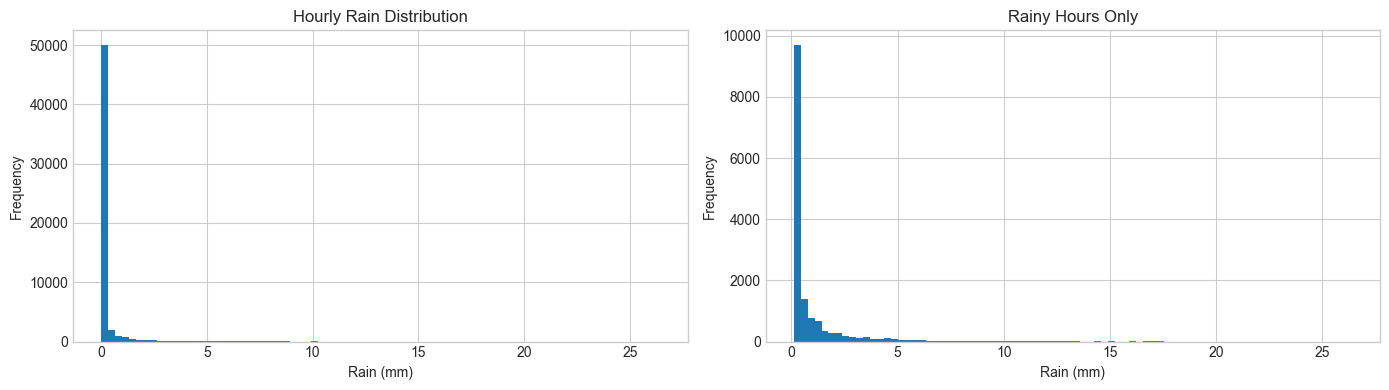

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

raw_df['rain'].plot(kind='hist', bins=80, ax=axes[0])
axes[0].set_title('Hourly Rain Distribution')
axes[0].set_xlabel('Rain (mm)')

raw_df.loc[raw_df['rain'] > 0, 'rain'].plot(kind='hist', bins=80, ax=axes[1])
axes[1].set_title('Rainy Hours Only')
axes[1].set_xlabel('Rain (mm)')

plt.tight_layout()

## 7. Rain Pattern by Time

In [28]:
time_df = raw_df.assign(
    hour=raw_df['timestamp'].dt.hour,
    month=raw_df['timestamp'].dt.month,
    date=raw_df['timestamp'].dt.date,
)

hourly_rain = time_df.groupby('hour')['rain'].agg(['mean', 'sum', lambda s: (s > 0).mean() * 100])
hourly_rain = hourly_rain.rename(columns={'<lambda_0>': 'rain_rate_percent'})
hourly_rain

,mean,sum,rain_rate_percent
hour,,,
0,0.319504,747.0,21.899059
1,0.330154,771.9,23.952096
2,0.316980,741.1,26.860565
3,0.291317,681.1,27.159966
4,0.277887,649.7,28.870830
5,0.277930,649.8,27.844311
6,0.265483,620.7,26.304534
7,0.228186,533.5,27.202737
8,0.218905,511.8,31.223268


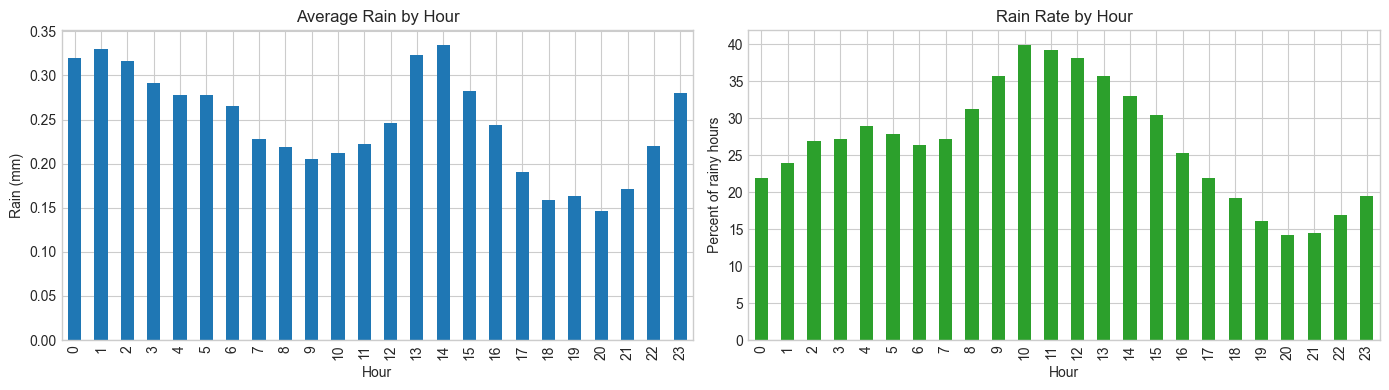

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

hourly_rain['mean'].plot(kind='bar', ax=axes[0])
axes[0].set_title('Average Rain by Hour')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Rain (mm)')

hourly_rain['rain_rate_percent'].plot(kind='bar', ax=axes[1], color='tab:green')
axes[1].set_title('Rain Rate by Hour')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Percent of rainy hours')

plt.tight_layout()

In [30]:
monthly_rain = time_df.groupby('month')['rain'].agg(['mean', 'sum', lambda s: (s > 0).mean() * 100])
monthly_rain = monthly_rain.rename(columns={'<lambda_0>': 'rain_rate_percent'})
monthly_rain

,mean,sum,rain_rate_percent
month,,,
1,0.064843,337.7,18.375576
2,0.100863,479.3,26.767677
3,0.101210,527.1,22.023810
4,0.141210,711.7,22.361111
5,0.301690,1535.0,28.321541
6,0.430324,1859.0,31.944444
7,0.392047,1750.1,35.976703
8,0.515435,2300.9,44.377240
9,0.582546,2516.6,46.875000


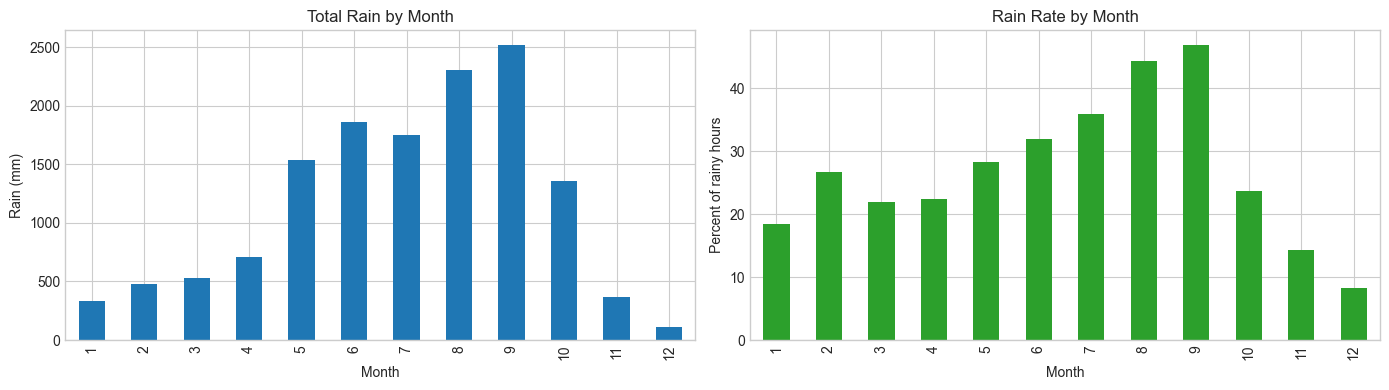

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

monthly_rain['sum'].plot(kind='bar', ax=axes[0])
axes[0].set_title('Total Rain by Month')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Rain (mm)')

monthly_rain['rain_rate_percent'].plot(kind='bar', ax=axes[1], color='tab:green')
axes[1].set_title('Rain Rate by Month')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Percent of rainy hours')

plt.tight_layout()

## 8. Time-Series View

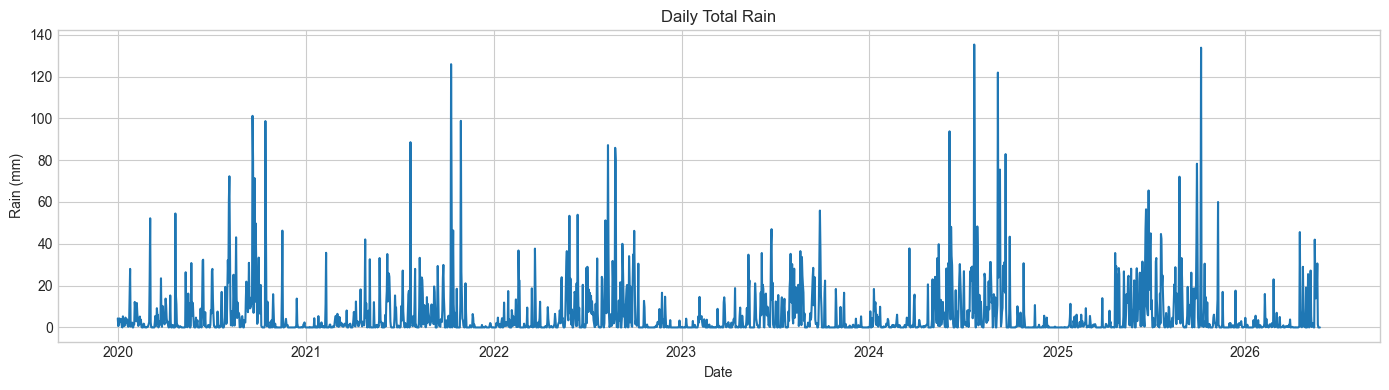

In [32]:
daily_rain = time_df.groupby('date')['rain'].sum()

plt.figure(figsize=(14, 4))
daily_rain.plot()
plt.title('Daily Total Rain')
plt.xlabel('Date')
plt.ylabel('Rain (mm)')
plt.tight_layout()

## 9. Weather Variables vs Rain

In [33]:
corr_with_rain = raw_df[BASE_COLUMNS].corr(numeric_only=True)['rain'].sort_values(ascending=False)
corr_with_rain.to_frame('correlation_with_rain')

,correlation_with_rain
rain,1.000000
precipitation,1.000000
cloud_cover_mid,0.222098
cloud_cover_high,0.216681
relative_humidity_2m,0.175959
cloud_cover,0.152987
dew_point_2m,0.131404
wind_gusts_10m,0.131261
cloud_cover_low,0.120043
wind_speed_10m,0.072779


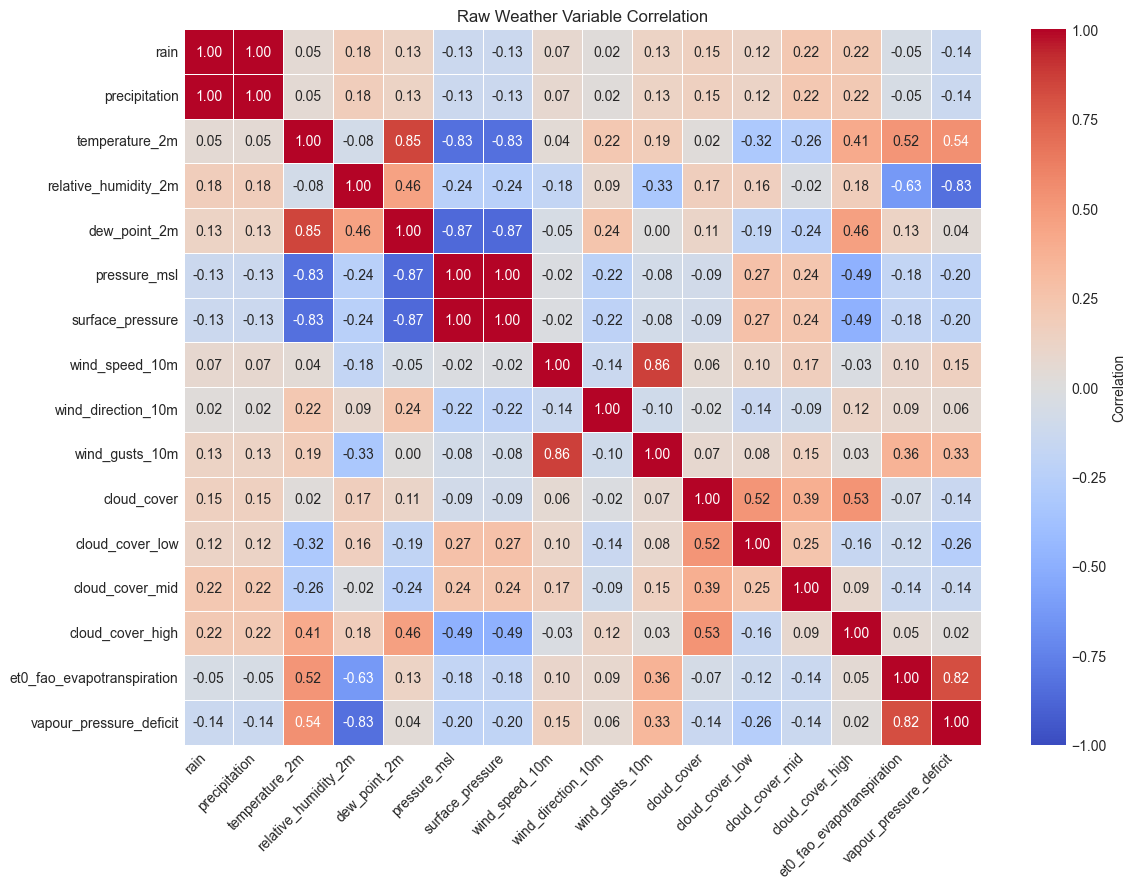

In [34]:
plt.figure(figsize=(12, 9))
corr_matrix = raw_df[BASE_COLUMNS].corr(numeric_only=True)
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    center=0,
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'label': 'Correlation'},
)
plt.title('Raw Weather Variable Correlation')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()